In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import os

import mlrose_hiive
from mlrose_hiive import QueensGenerator, MaxKColorGenerator, TSPGenerator
# from mlrose_hiive import SARunner, GARunner, NNGSRunner, RHCRunner, MIMICRunner
from mlrose_hiive import QueensGenerator
from mlrose_hiive import SARunner

In [2]:
EXPERIMENT_NAME = 'SA_Queens_GridSearch'
SEED = 0
# PROBLEM_SIZE_LIST = [8]
PROBLEM_SIZE_LIST = [20]
ITERATIONS_LIST = [1e9]
MAX_ATTEMPTS_LIST = [100]
TEMPERATURE_LIST = [1, 2, 3]
DECAY_LIST = {
    'GeomDecay': mlrose_hiive.GeomDecay, 
    'ExpDecay': mlrose_hiive.ExpDecay, 
    'ArithDecay': mlrose_hiive.ArithDecay,
}
NUM_RUNS = 5

In [3]:
output_dir = f'metrics/{EXPERIMENT_NAME}'
os.makedirs(output_dir, exist_ok=True)

In [4]:
all_df = pd.DataFrame()
group_i = 0
run_i = 0
for problem_size in PROBLEM_SIZE_LIST:
    for max_iterations in ITERATIONS_LIST:
        for max_attempts in MAX_ATTEMPTS_LIST:
            for start_temperature in tqdm(TEMPERATURE_LIST):
                for decay_str, decay_cls in DECAY_LIST.items():
                    for i in range(NUM_RUNS):
                        problem = QueensGenerator().generate(seed=SEED+i, size=8)
                        sa = SARunner(
                            problem=problem,
                            experiment_name='dontcare',
                            output_directory='./results/grid_search_queens_rhc',
                            seed=SEED+i,
                            iteration_list=[max_iterations],
                            max_attempts=max_attempts,
                            temperature_list=[start_temperature],
                            decay_list=[decay_cls],
                        )
                        _, df_run_curves = sa.run()
                        df_run_curves['group_number'] = group_i
                        df_run_curves['run_number'] = run_i
                        df_run_curves['problem_size'] = problem_size
                        df_run_curves['max_iterations'] = max_iterations
                        df_run_curves['max_attempts'] = max_attempts
                        df_run_curves['start_temperature'] = start_temperature
                        df_run_curves['decay_type'] = decay_str

                        all_df = pd.concat([all_df, df_run_curves], axis=0)
                        run_i += 1
                    group_i += 1
all_df.reset_index(inplace=True, drop=True)

100%|██████████| 3/3 [02:56<00:00, 58.86s/it]


In [5]:
all_df['Fitness'] = -1 * all_df['Fitness']

In [6]:
all_df.to_csv(os.path.join(output_dir, 'learning_curve.csv'), index=False)

In [7]:
len(all_df['run_number'].unique())

45

In [8]:
all_df['Fitness'].max()

-0.0

In [9]:
for run_i in sorted(all_df['run_number'].unique()):
    mask = all_df['run_number'] == run_i
    temp_df = all_df[mask]
    all_df.loc[mask, 'total_iterations'] = temp_df['Iteration'].max()
    all_df.loc[mask, 'total_time'] = temp_df['Time'].max()
    all_df.loc[mask, 'best_fitness'] = temp_df['Fitness'].max()
    all_df.loc[mask, 'total_fevals'] = temp_df['FEvals'].max()
run_df = all_df[[
    'run_number', 'group_number', 'problem_size', 'max_iterations', 'max_attempts', 'start_temperature', 'decay_type',
    'total_iterations', 'total_time', 'best_fitness', 'total_fevals']]
run_df.drop_duplicates(inplace=True)
len(run_df)

45

In [10]:
for group_i in sorted(run_df['group_number'].unique()):
    mask = run_df['group_number'] == group_i
    temp_df = run_df[mask]
    for key in 'total_iterations', 'total_time', 'best_fitness', 'total_fevals':
        run_df.loc[mask, f"{key}_mean"] = temp_df[key].mean()
        run_df.loc[mask, f"{key}_std"] = temp_df[key].std()
group_df = run_df[[
    'group_number', 'problem_size', 'max_iterations', 'max_attempts', 'start_temperature', 'decay_type',
    'total_iterations_mean', 'total_iterations_std', 'total_time_mean', 'total_time_std', 'best_fitness_mean',
    'best_fitness_std', 'total_fevals_mean', 'total_fevals_std']]
group_df.drop_duplicates(inplace=True)
len(group_df)

9

In [11]:
group_df

,group_number,problem_size,max_iterations,max_attempts,start_temperature,decay_type,total_iterations_mean,total_iterations_std,total_time_mean,total_time_std,best_fitness_mean,best_fitness_std,total_fevals_mean,total_fevals_std
0,0,20,1.000000e+09,100,1,GeomDecay,453.8,241.559930,0.064405,0.037793,0.0,0.000000,525.2,248.362034
2274,1,20,1.000000e+09,100,1,ExpDecay,717.0,270.892045,0.109119,0.047914,0.0,0.000000,844.6,280.404708
5864,2,20,1.000000e+09,100,1,ArithDecay,2465.6,1679.759149,0.873927,0.716563,0.0,0.000000,3603.2,2409.825969
18197,3,20,1.000000e+09,100,2,GeomDecay,657.2,894.065266,0.139045,0.230594,0.0,0.000000,773.0,960.424906
21488,4,20,1.000000e+09,100,2,ExpDecay,614.4,328.023322,0.094366,0.052756,0.0,0.000000,780.4,389.736193
24565,5,20,1.000000e+09,100,2,ArithDecay,9368.6,5352.859638,9.279678,8.991307,0.0,0.000000,15195.6,8013.153237
71413,6,20,1.000000e+09,100,3,GeomDecay,528.2,525.266313,0.087639,0.101866,-0.2,0.447214,661.4,585.312566
74059,7,20,1.000000e+09,100,3,ExpDecay,761.8,415.478880,0.130439,0.093784,0.0,0.000000,1019.6,444.551797
77873,8,20,1.000000e+09,100,3,ArithDecay,15516.8,8440.453436,24.263903,16.042759,0.0,0.000000,26761.0,14338.977457


In [12]:
max_fit = group_df['best_fitness_mean'].max()
best_df = group_df[group_df['best_fitness_mean'] == max_fit]
len(best_df)

8

<Axes: >

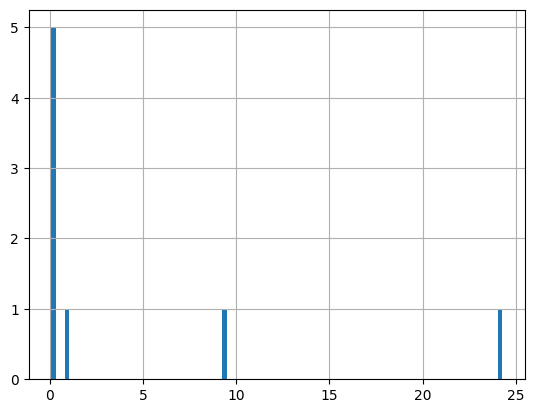

In [13]:
best_df['total_time_mean'].hist(bins=100)

<Axes: >

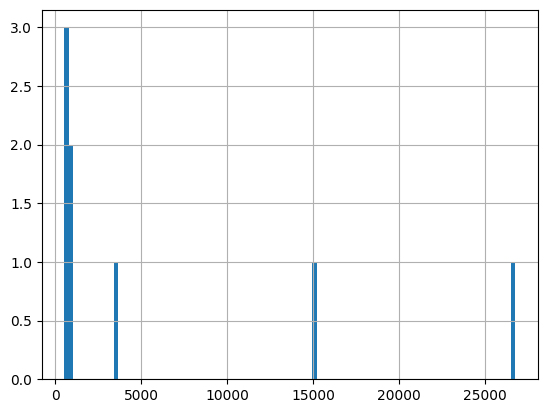

In [14]:
best_df['total_fevals_mean'].hist(bins=100)

In [15]:
min_time = best_df['total_time_mean'].min()
min_fevals = best_df['total_fevals_mean'].min()
min_time, min_fevals

(0.06440488320000001, 525.2)

In [16]:
best_df[best_df['total_time_mean'] == min_time]['total_fevals_mean']

0    525.2
Name: total_fevals_mean, dtype: float64

In [17]:
import matplotlib.pyplot as plt

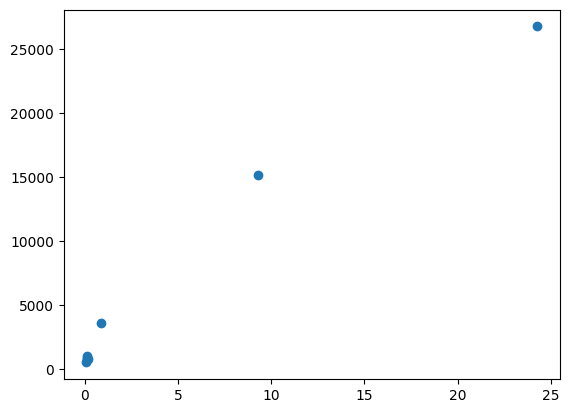

In [18]:
plt.plot(best_df['total_time_mean'], best_df['total_fevals_mean'], 'o')

In [19]:
best_df[best_df['total_time_mean'] == min_time]

,group_number,problem_size,max_iterations,max_attempts,start_temperature,decay_type,total_iterations_mean,total_iterations_std,total_time_mean,total_time_std,best_fitness_mean,best_fitness_std,total_fevals_mean,total_fevals_std
0,0,20,1.000000e+09,100,1,GeomDecay,453.8,241.55993,0.064405,0.037793,0.0,0.0,525.2,248.362034


In [20]:
# problem_size	max_iterations	max_attempts	max_restarts	total_iterations_mean	total_iterations_std	total_time_mean	total_time_std	best_fitness_mean	best_fitness_std	total_fevals_mean	total_fevals_std	total_restarts_mean	total_restarts_std
# 8	            1.000000e+09	50	            100	            139.0	                0.0	                    0.015603	    0.000175	    0.0	                0.0	                1501.0	            0.0	                15.0	            0.0

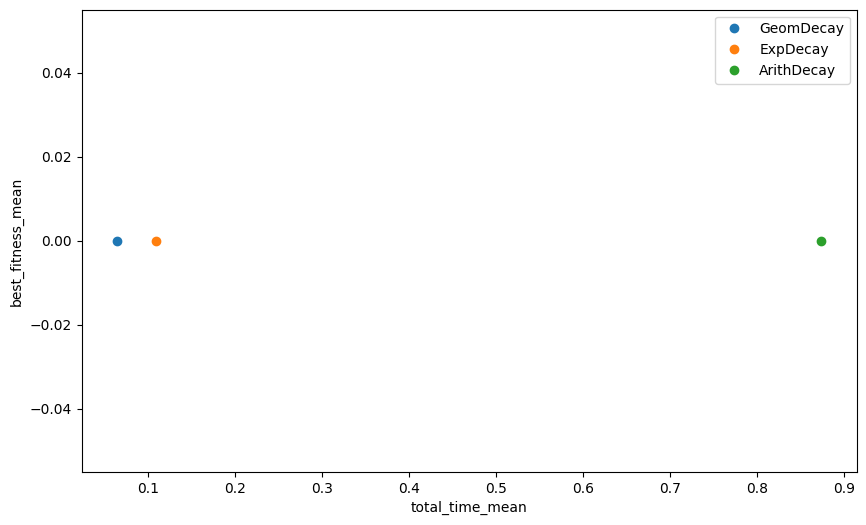

In [26]:
s_df = group_df[group_df['start_temperature'] == 1]
# plot the best_fitness_mean vs. total_time_mean for each decay_type
plt.figure(figsize=(10, 6))
plt.plot(s_df[s_df['decay_type'] == 'GeomDecay']['total_time_mean'], s_df[s_df['decay_type'] == 'GeomDecay']['best_fitness_mean'], 'o', label='GeomDecay')
plt.plot(s_df[s_df['decay_type'] == 'ExpDecay']['total_time_mean'], s_df[s_df['decay_type'] == 'ExpDecay']['best_fitness_mean'], 'o', label='ExpDecay')
plt.plot(s_df[s_df['decay_type'] == 'ArithDecay']['total_time_mean'], s_df[s_df['decay_type'] == 'ArithDecay']['best_fitness_mean'], 'o', label='ArithDecay')
plt.xlabel('total_time_mean')
plt.ylabel('best_fitness_mean')
plt.legend()